# Will they stay in our bank or choose an other one? Deep Learning approach

<h1 style="font-family: 'poppins'; font-weight: bold; color: Green;">👨‍💻Author: Rohit Jangid</h1>

[![GitHub](https://img.shields.io/badge/GitHub-Profile-blue?style=for-the-badge&logo=github)](https://github.com/rohitjanggid) 
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin)](https://www.linkedin.com/in/rohit-jangid-r950/)  
[![Twitter/X](https://img.shields.io/badge/Twitter-Profile-blue?style=for-the-badge&logo=twitter)](https://x.com/rohit_janggid) 
[![Email](https://img.shields.io/badge/Email-Contact%20Me-red?style=for-the-badge&logo=email)](mailto:rohitjangid95095@gmail.com)


## AIM: `We will classifiy the customers who will stay in our bank or leave the bank using deep learning approach`

`Data Description:`

- Customer ID: A unique identifier for each customer

- Surname: The customer's surname or last name

- Credit Score: A numerical value representing the customer's credit score

- Geography: The country where the customer resides

- Gender: The customer's gender

- Age: The customer's age.

- Tenure: The number of years the customer has been with the bank

- Balance: The customer's account balance

- NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)

- HasCrCard: Whether the customer has a credit card

- IsActiveMember: Whether the customer is an active member

- EstimatedSalary: The estimated salary of the customer

- Exited: Whether the customer has churned (Target Variable)

In [21]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# remove warnings 
import warnings
warnings.filterwarnings('ignore')

In [22]:
# load the dataset
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')

In [23]:
# train dataset and exploration
df_train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [24]:
df = df_train.copy()

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,165034.0,8.251650e+04,47641.356500,0.00,41258.25,82516.5,1.237748e+05,165033.00
CustomerId,165034.0,1.569201e+07,71397.816791,15565701.00,15633141.00,15690169.0,1.575682e+07,15815690.00
CreditScore,165034.0,6.564544e+02,80.103340,350.00,597.00,659.0,7.100000e+02,850.00
Age,165034.0,3.812589e+01,8.867205,18.00,32.00,37.0,4.200000e+01,92.00
Tenure,165034.0,5.020353e+00,2.806159,0.00,3.00,5.0,7.000000e+00,10.00
Balance,165034.0,5.547809e+04,62817.663278,0.00,0.00,0.0,1.199395e+05,250898.09
NumOfProducts,165034.0,1.554455e+00,0.547154,1.00,1.00,2.0,2.000000e+00,4.00
HasCrCard,165034.0,7.539537e-01,0.430707,0.00,1.00,1.0,1.000000e+00,1.00
IsActiveMember,165034.0,4.977702e-01,0.499997,0.00,0.00,0.0,1.000000e+00,1.00
EstimatedSalary,165034.0,1.125748e+05,50292.865585,11.58,74637.57,117948.0,1.551525e+05,199992.48


In [27]:
df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [28]:
cat_cols = [ 'Geography', 'Gender','Tenure', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'Exited']

num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

# find the value counts of the categorical columns 
for col in cat_cols: 
    print(df[col].value_counts())
    print()

Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64

Gender
Male      93150
Female    71884
Name: count, dtype: int64

Tenure
2     18045
7     17810
4     17554
8     17520
5     17268
1     16760
9     16709
3     16630
6     15822
10     5909
0      5007
Name: count, dtype: int64

NumOfProducts
2    84291
1    77374
3     2894
4      475
Name: count, dtype: int64

HasCrCard
1.0    124428
0.0     40606
Name: count, dtype: int64

IsActiveMember
0.0    82885
1.0    82149
Name: count, dtype: int64

Exited
0    130113
1     34921
Name: count, dtype: int64



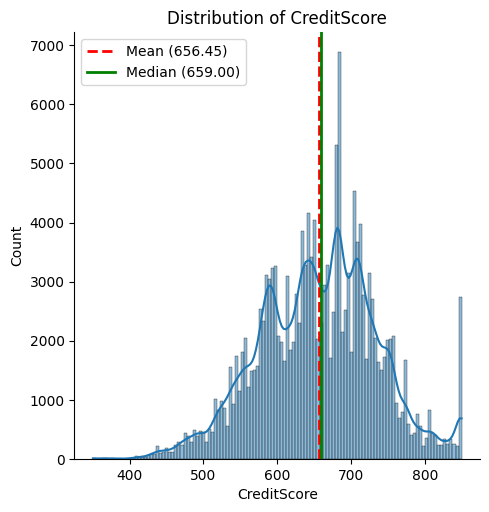

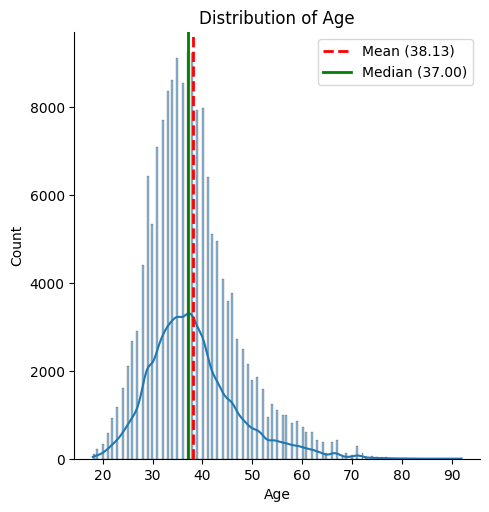

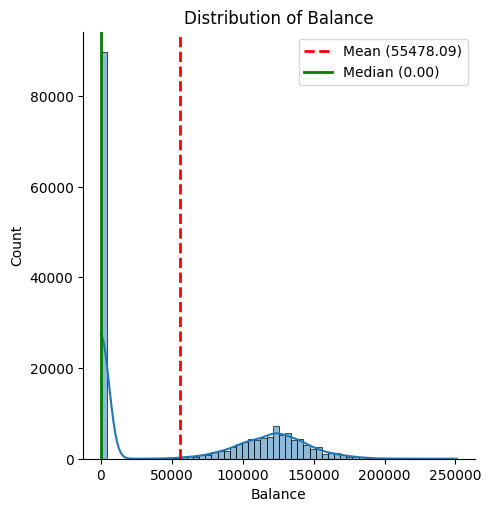

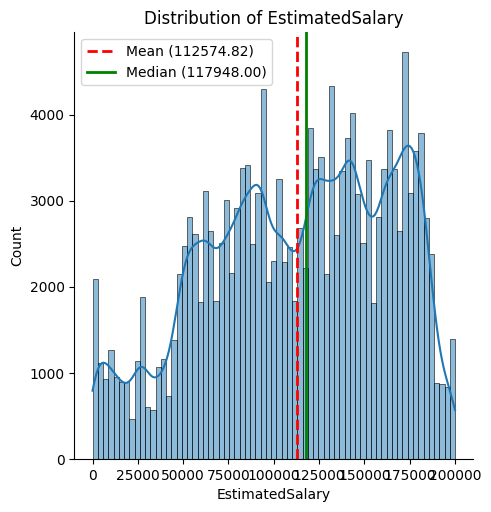

In [29]:
# create histogram of numarical columns
for col in num_cols:
    mean = df[col].mean()
    median = df[col].median()
    g = sns.displot(df[col], kde=True)
    # get the underlying Axes
    ax = getattr(g, "ax", None)
    if ax is None:
        ax = g.axes.flatten()[0]
    ax.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean:.2f})')
    ax.axvline(median, color='green', linestyle='-', linewidth=2, label=f'Median ({median:.2f})')
    ax.set_title(f'Distribution of {col}')
    ax.legend()
    plt.show()

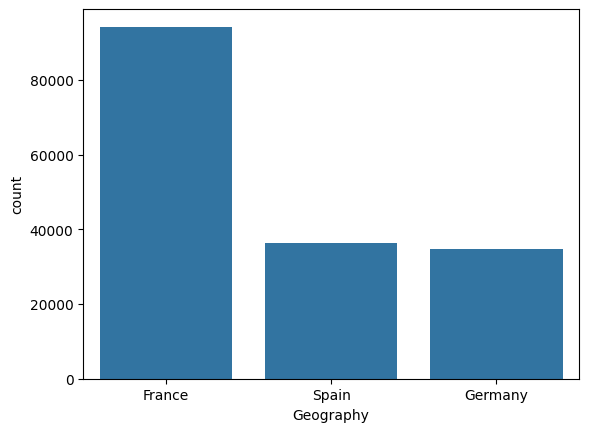

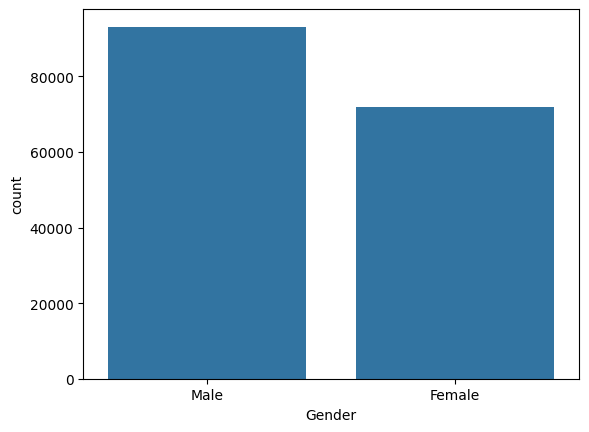

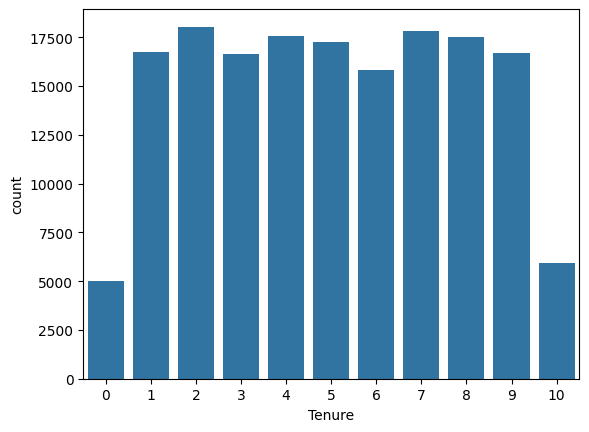

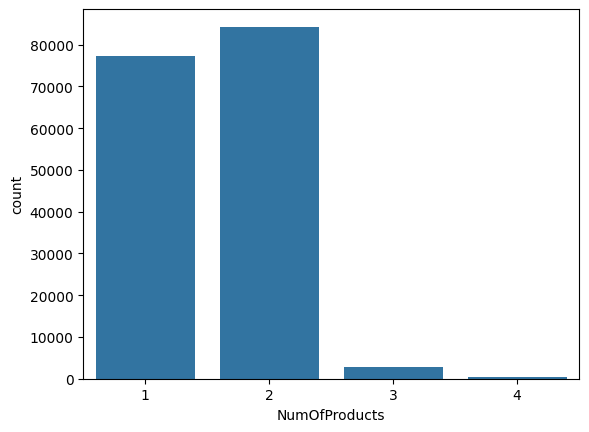

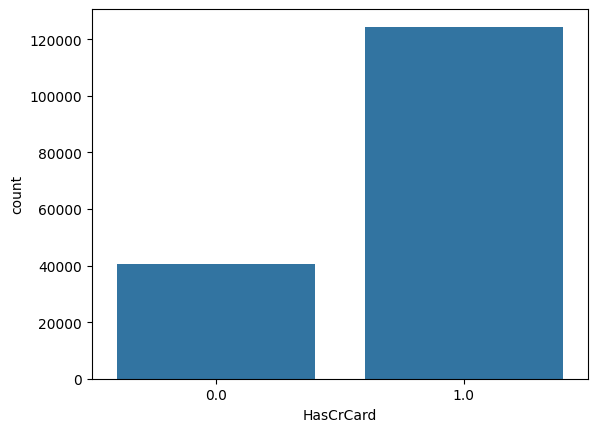

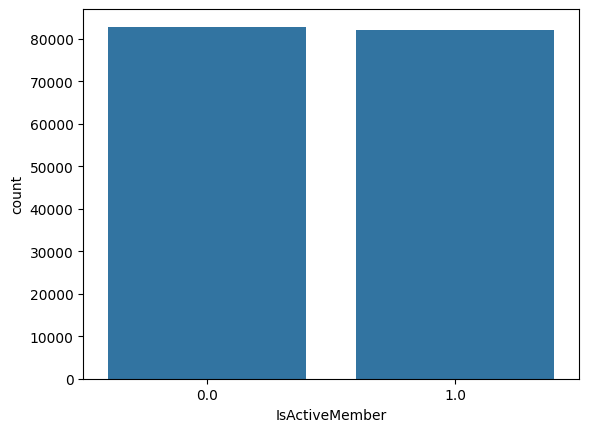

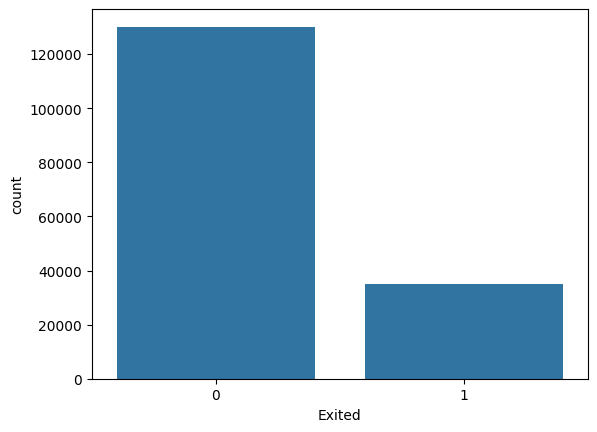

In [30]:
# create a count plot for each categorical column
for col in cat_cols:
    sns.countplot(df, x = df[col])
    plt.show()

In [31]:
# print the numbers of rows and columns
print(f"The train dataset has {df.shape[0]} rows and {df.shape[1]} columns")

The train dataset has 165034 rows and 14 columns


In [32]:
# Drop unnecessary columns and split the data into X and y 
X = df.drop(['id', 'CustomerId', 'Surname', 'Exited'], axis=1)
y = df['Exited']

# encode the categorical column having object data type using label encoder
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

for col in cat_cols:
    if col in X.columns:
        X[col] = label_encoder.fit_transform(X[col])
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,668,0,1,33.0,3,0.00,1,1,0,181449.97
1,627,0,1,33.0,1,0.00,1,1,1,49503.50
2,678,0,1,40.0,10,0.00,1,1,0,184866.69
3,581,0,1,34.0,2,148882.54,0,1,1,84560.88
4,716,2,1,33.0,5,0.00,1,1,1,15068.83


In [33]:
y.value_counts()

Exited
0    130113
1     34921
Name: count, dtype: int64

In [34]:
# train test split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Neural Network Architecture

Epoch 1/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6757 - loss: 26.5100 - val_accuracy: 0.7887 - val_loss: 2.9685
Epoch 2/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7417 - loss: 0.8005 - val_accuracy: 0.7893 - val_loss: 0.5292
Epoch 3/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7829 - loss: 1.0485 - val_accuracy: 0.7893 - val_loss: 0.5066
Epoch 4/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.7882 - loss: 0.5157 - val_accuracy: 0.7893 - val_loss: 0.5150
Epoch 5/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.7882 - loss: 0.5164 - val_accuracy: 0.7893 - val_loss: 0.5149
Epoch 6/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7879 - loss: 0.5198 - val_accuracy: 0.7893 - val_loss: 0.5150
Epoch 7/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.7882 - loss: 0.5209 - val_accuracy: 0.7893 - val_loss: 0.5149
Epoch 8/100
4126/4126 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7882 - loss: 

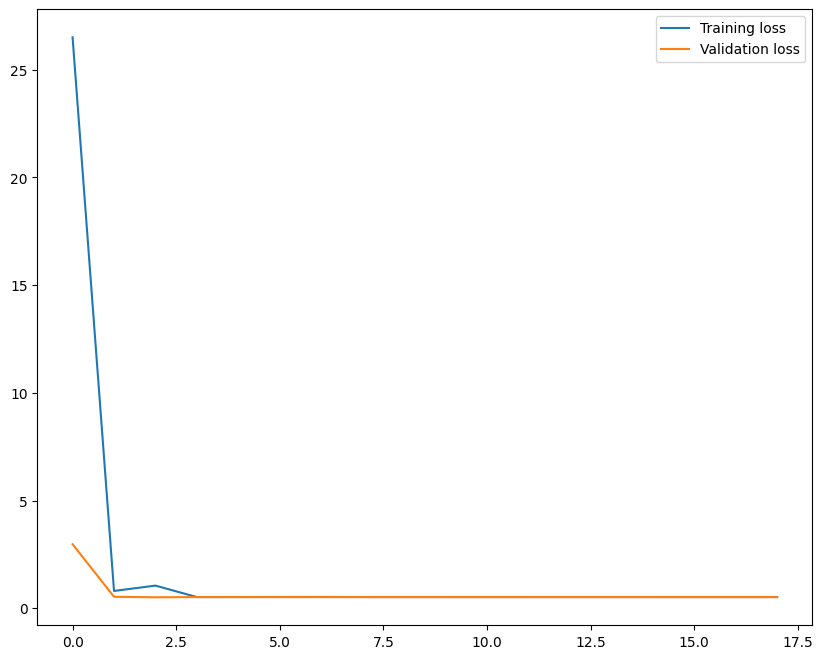

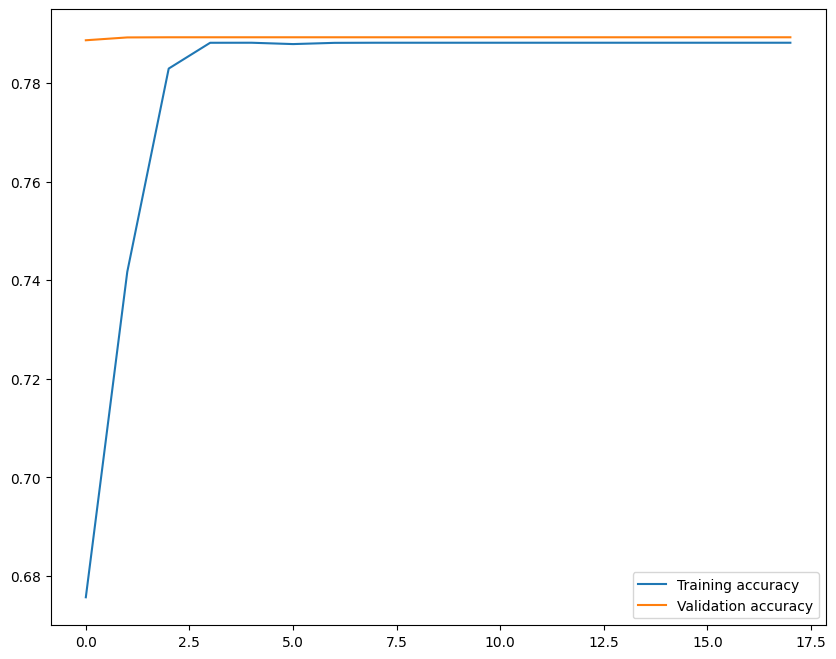

CPU times: total: 2min 37s
Wall time: 1min 55s


In [35]:
%%time
# create a deep neural network using tensorflow for binary classification
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer 1
    tf.keras.layers.Dense(16, activation='relu'), # Hidden layer 2
    tf.keras.layers.Dense(8, activation='relu'), # Hidden layer 3
    
    tf.keras.layers.Dense(1, activation='sigmoid') # Output layer
])

# Define the callback function
early_stopping = EarlyStopping(patience=15)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train the model and plot the training and testing loss and accuracy at each epoc
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_data=(X_test, y_test), 
                    callbacks=[early_stopping])

# plot the training and testing loss and accuracy at each epoc
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(history.history['loss'], label='Training loss')
ax.plot(history.history['val_loss'], label='Validation loss')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(history.history['accuracy'], label='Training accuracy')
ax.plot(history.history['val_accuracy'], label='Validation accuracy')
ax.legend()
plt.show()

# XGB classifier

Accuracy Score: 0.8669676129305904
Precision Score: 0.7403449568803899
Recall Score: 0.5677929547088426
F1 Score: 0.6426885832858654


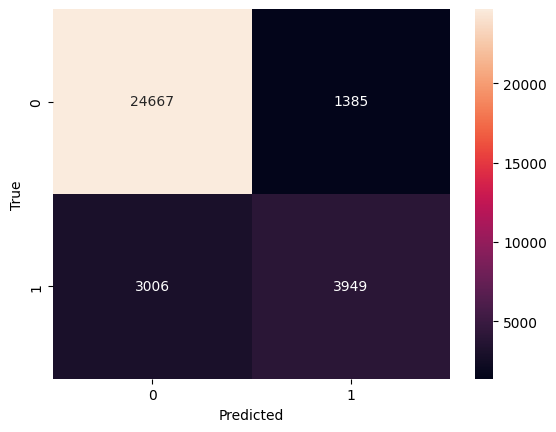

In [36]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# train the xgboost model 
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# predict the test data
y_pred = xgb.predict(X_test)

print('Accuracy Score:', accuracy_score(y_test, y_pred))
print('Precision Score:', precision_score(y_test, y_pred))
print('Recall Score:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))

# plot the confusion metrics
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [38]:
from sklearn.preprocessing import LabelEncoder

# convert categorical columns to numarical values 
le = LabelEncoder()
df_test['Geography'] = le.fit_transform(df_test['Geography'])
df_test['Gender'] = le.fit_transform(df_test['Gender'])

# predict the test data and create a submission file of probability of each class
y_pred = xgb.predict_proba(df_test.drop(['id', 'CustomerId', 'Surname'], axis=1))
submission['Exited'] = y_pred[:, 1]
submission.to_csv('data/submission.csv', index=False)